In [1]:
import numpy as np

import matplotlib as mpl
import modules.tools as tools
import modules.models as models

import scipy.sparse.linalg as sla
import sys

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import pickle
print(os.path.dirname(os.getcwd()))

/Users/alexanderlau/Documents/Science/Projects/NLSM_flat_band/Zenodo


In [3]:
from tqdm.notebook import tqdm # to have a progress bar for the loop

In [4]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('font', size=16)

In [5]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

In [6]:
from numpy import cos, sin, pi, exp, sqrt

### Unstrained model

In [7]:
# calculate spectral function
Nx = 201
Ny = Nx

Ef = 0.0

kxs = np.linspace(-pi,pi,Nx)
kys = np.linspace(-pi,pi,Ny)
S = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H0(kx, ky, kz=0.0, t1=1.0, t2=1.)

for i,kx in enumerate(kxs):
    for j,ky in enumerate(kys):
        S[j,i] = tools.spectral_function_2D((kx,ky), ham, Ef)     

In [8]:
# Check the mirror eigenvalues
evals = np.zeros((Nx,2))
evecs = np.zeros((Nx,2,2), dtype=complex)
mirror = np.zeros((Nx,2))

for i,k in enumerate(kxs):
    evals[i,:], evecs[i,:,:] = np.linalg.eigh(ham(k,0.0))
    mirror[i,:] = np.real(np.diag(np.transpose(np.conj(evecs[i,:,:])) @ sz @ evecs[i,:,:]))

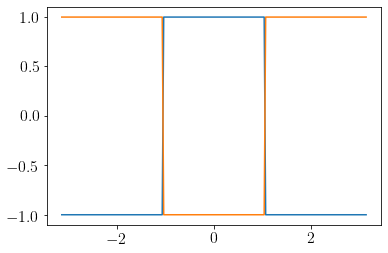

In [9]:
plt.plot(kxs,mirror)

Text(0, 0.5, '$k_y$')

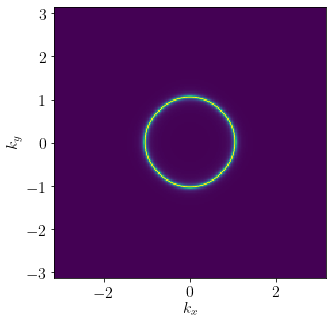

In [10]:
plt.figure(figsize=(5,5))
plt.imshow(S.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

Text(0, 0.5, '$E$')

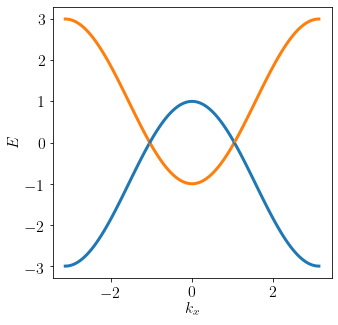

In [11]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

kn1 = 67
kn2 = 134

plt.figure(figsize=(5,5))
plt.plot(kxs[0:kn1],evals[0:kn1,0],c=colors[0],lw=3.0)
plt.plot(kxs[kn1:kn2],evals[kn1:kn2,0],c=colors[1],lw=3.0)
plt.plot(kxs[kn2:],evals[kn2:,0],c=colors[0],lw=3.0)

plt.plot(kxs[0:kn1],evals[0:kn1,1],c=colors[1],lw=3.0)
plt.plot(kxs[kn1:kn2],evals[kn1:kn2,1],c=colors[0],lw=3.0)
plt.plot(kxs[kn2:],evals[kn2:,1],c=colors[1],lw=3.0)

#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$E$')

### Finite Model with strain

The strain term is implemented as a position-dependent prefactor $1-\frac{z}{R}$ of the hopping parameter w.r.t. the x direction. This describes a ray-like strain profile. It is a leading-order approximation and is only valid for small strain.

Let's look at the two limiting cases:
* For $z=-R$, we are at the focal point of the ray where the $x$ distance between adjacent sites goes to zero. Here, the prefactor is $1-\frac{z}{R}\rightarrow 2$. This is not realistic as we would expect an exponential dependence on the distance.
* For $z=R$, the hopping term vanishes as $1-\frac{z}{R}\rightarrow 0$. Also this is not physical, as the hopping amplitude should decline exponentially with $z$.

Hence, this approximation is only valid for $|z|\ll R$.

#### Negligible strain

In [31]:
R = 1e10
t1 = 0.25
t2 = 0.8
Lz = 100

In [32]:
# calculate spectral function
Nx=51
Ny=51
Ef = 0.0

kxs = np.linspace(-pi,pi,Nx)
kys = np.linspace(-pi,pi,Ny)
S = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H_strain(kx, ky, Lz, R, t1, t2)

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S[i,j] = tools.spectral_function_2D((kx,ky), ham, Ef)     

Text(0, 0.5, '$k_y$')

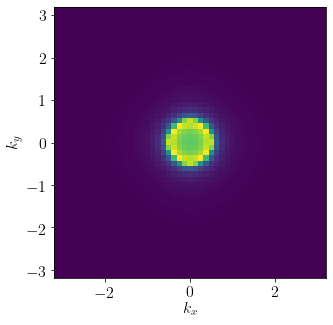

In [33]:
plt.figure(figsize=(5,5))
plt.imshow(S.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')

In [34]:
Nx = 51
Ny = Nx

kxs = np.linspace(-1.0,1.0,Nx)
kys = np.linspace(-1.0,1.0,Ny)

evals = np.zeros((Nx,Ny,2*Lz))
evecs = np.zeros((Nx,Ny,2*Lz,2*Lz), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        evals[i,j,:], evecs[i,j,:,:] = np.linalg.eigh(models.H_strain(kx, ky, Lz, R, t1, t2))

0.0


(-1.0, 1.0)

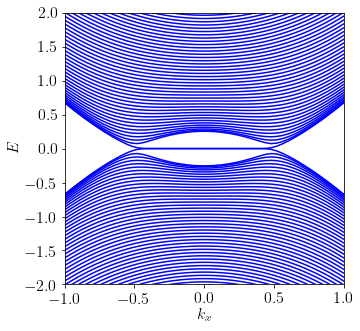

In [35]:
i=25
print(kys[i])
evals_k = evals[:,i,:]

plt.figure(figsize=(5,5))
plt.plot(kxs,evals_k,'b-')
plt.xlabel('$k_x$')
plt.ylabel('$E$')
plt.ylim(-2,2)
plt.xlim(-1.0,1.0)

In [40]:
print(evals_k[25,98:102])

[-2.54523103e-01 -1.31491402e-08  1.31491397e-08  2.54523103e-01]


There are two zero-energy states at k=(0,0)

In [41]:
evecs_1 = evecs[:,:,:,99]
evecs_2 = evecs[:,:,:,100]

In [42]:
densities_1 = np.zeros((Nx, Ny, Lz))
densities_2 = np.zeros((Nx, Ny, Lz))

for i in range(Nx):
    for j in range(Ny):
        densities_1[i,j,:] = tools.density(evecs_1[i,j,:],2)
        densities_2[i,j,:] = tools.density(evecs_2[i,j,:],2)

Text(0, 0.5, '$|\\psi(z)|^2$')

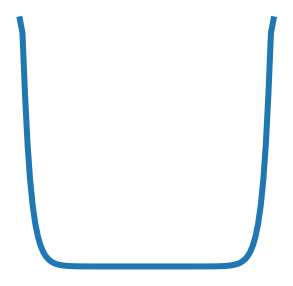

In [44]:
plt.figure(figsize=(5,5))
plt.plot(densities_1[25,25],lw=6.0)
#plt.plot(densities_2[50,50],lw=3.0)
plt.axis('off')
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|^2$')

The zero-energy states are surface states corresponding to the drumhead surface states of nodal-line semimetals

#### Sizable strain

Ensure that $L_z/2 < R$.

In [45]:
R = 400
t1 = 0.25
t2 = 0.8
Lz = 100

In [48]:
# Calculate spectral function
Nx = 25
Ny = Nx

Ef = 0.0

kxs = np.linspace(-0.8,0.8,Nx)
kys = np.linspace(-0.8,0.8,Ny)
S = np.zeros((Nx,Ny))

ham = lambda kx, ky: models.H_strain(kx, ky, Lz, R, t1, t2)

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        S[i,j] = tools.spectral_function_2D((kx,ky), ham, Ef)     

Text(0, 0.5, '$ak_y$')

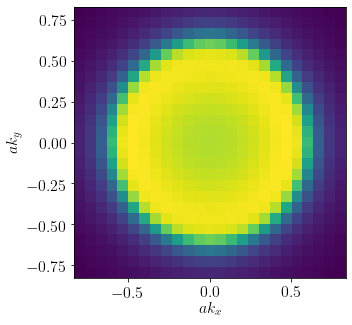

In [49]:
plt.figure(figsize=(5,5))
plt.imshow(S.transpose(), extent=tools.imshow_extent(kxs,kys), aspect=1)
#plt.axvline(0)
#plt.axhline(0)
plt.xlabel('$ak_x$')
plt.ylabel('$ak_y$')

In [50]:
Nx = 51
Ny = 51

kxs = np.linspace(-1.0,1.0,Nx)
kys = np.linspace(-1.0,1.0,Ny)

evals = np.zeros((Nx,Ny,2*Lz))
evecs = np.zeros((Nx,Ny,2*Lz,2*Lz), dtype='complex')

for i,kx in tqdm(list(enumerate(kxs))):
    for j,ky in enumerate(kys):
        evals[i,j,:], evecs[i,j,:,:] = np.linalg.eigh(models.H_strain(kx, ky, Lz, R, t1, t2))

0.0


(-1.0, 1.0)

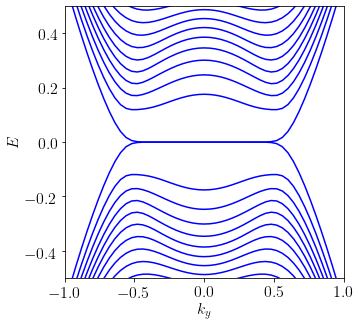

In [51]:
i=25
print(kys[i])
evals_k = evals[:,i,:]
#evals_k = evals[:,i,:]

plt.figure(figsize=(5,5))
plt.plot(kxs,evals_k,'b-')
plt.xlabel('$k_y$')
plt.ylabel('$E$')
plt.ylim(-0.5,0.5)
plt.xlim(-1.0,1.0)

In [52]:
Nev = 25
print(evals_k[Nev,Lz-2:Lz+2])

[-1.75995923e-01 -3.39157358e-09  3.39157444e-09  1.75995923e-01]


There are two zero-energy states at k=(0,0)

Look at the spatial profile of these states:

In [53]:
evecs_1 = evecs[:,:,:,Lz-1]
evecs_2 = evecs[:,:,:,Lz]

In [54]:
densities_1 = np.zeros((Nx, Ny, Lz))
densities_2 = np.zeros((Nx, Ny, Lz))

for i in range(Nx):
    for j in range(Ny):
        densities_1[i,j,:] = tools.density(evecs_1[i,j,:],2)
        densities_2[i,j,:] = tools.density(evecs_2[i,j,:],2)

In [55]:
# basis change in the space of zero-energy states
# splits the states into drumhead and LL states
evecs_1s = (evecs[:,:,:,Lz-1] + evecs[:,:,:,Lz])/sqrt(2.)
evecs_2s = (evecs[:,:,:,Lz-1] - evecs[:,:,:,Lz])/sqrt(2.)

In [56]:
densities_1s = np.zeros((Nx, Ny, Lz))
densities_2s = np.zeros((Nx, Ny, Lz))

for i in range(Nx):
    for j in range(Ny):
        densities_1s[i,j,:] = tools.density(evecs_1s[i,j,:],2)
        densities_2s[i,j,:] = tools.density(evecs_2s[i,j,:],2)

In [57]:
print(kxs[i]) #17,50,83
print(kys[26])

1.0
0.040000000000000036


Text(0, 0.5, '$|\\psi(z)|$')

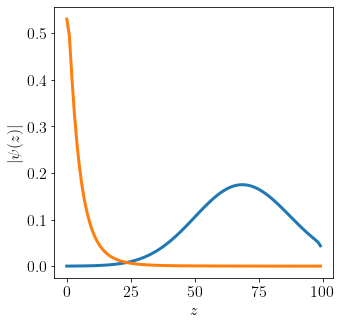

In [60]:
i=15
plt.figure(figsize=(5,5))
plt.plot(np.sqrt(densities_1s[i,26]),lw=3.0)
plt.plot(np.sqrt(densities_2s[i,26]),lw=3.0)
#plt.ylim(-0.01,0.53)
plt.xlabel('$z$')
plt.ylabel('$|\psi(z)|$')

There is one bulk LL state with a Gaussian profile whose center shifts around depending on the momentum. In addition, there is still one drumhead surface state.

By studying the transition from negligible to sizable strain, I find that one of the drumhead surface states evolves into a bulk LL state. In the considered cases, this is always the drumhead state from the top surface. In contrast to that, the drumhead state from the bottom surface stays in tact.

### Counting the number of zero-energy states

In [64]:
Nx = 25
Ny = Nx
t1 = 0.25
t2 = 0.8

kxs = np.linspace(0,1.2,Nx)
kys = np.linspace(0,1.2,Ny)

In [65]:
Lzs = range(50,525,25)
R0 = 10e8
R1 = 400

In [66]:
spectra_full0 = []
spectra_full1 = []

In [ ]:
# look at all eigenstates

for Lz in Lzs:
    print("Lz = ", Lz)
    evals0 = np.zeros((Nx,Ny,2*Lz))
    evals1 = np.zeros((Nx,Ny,2*Lz))
    for i,kx in tqdm(list(enumerate(kxs))):
        for j,ky in enumerate(kys):
            ham1 = models.H_strain(kx, ky, Lz, R0, t1, t2)
            ham2 = models.H_strain(kx, ky, Lz, R1, t1, t2)
            
            evals0[i,j,:] = np.linalg.eigvalsh(ham1)
            evals1[i,j,:] = np.linalg.eigvalsh(ham1)

    spectra_full0.append(np.abs(evals0))
    spectra_full1.append(np.abs(evals1))

In [69]:
dE = 1e-3 # energy window

In [70]:
n_states_full0 = []
n_states_full1 = []

for j,spectrum in tqdm(list(enumerate(spectra_full0))):
    n_states_full0.append(sum([E<dE for E in spectrum.flatten()]))

for j,spectrum in tqdm(list(enumerate(spectra_full1))):
    n_states_full1.append(sum([E<dE for E in spectrum.flatten()]))


In [71]:
Qx = np.arccos((2.-t1)/2.)

n0_lim = pi* Qx**2 / (1.2/24 *1.2/24)/2
print(n0_lim)

160.46579540241063


In [72]:
Lx = 2*pi/(1.2/24)
Ly = 2*pi/(1.2/24)

lB = np.sqrt(Qx*R1)
n_LL = lambda Lz: Qx*Lx*Ly*Lz/(2*pi* lB**2)/4

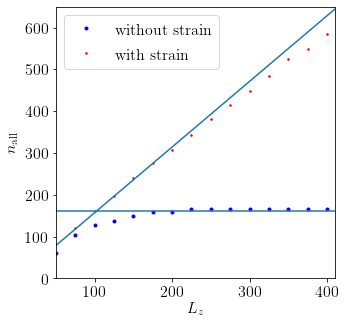

In [73]:
plt.figure(figsize=(5,5))
plt.plot(Lzs, n_states_full0, 'b.', ms=6, label='without strain')
plt.plot(Lzs, n_states_full1, 'r.', ms=3, label='with strain')
plt.plot(Lzs, n_LL(Lzs))
plt.axhline(n0_lim)
plt.ylabel('$n_\mathrm{all}$')
plt.xlabel('$L_z$')
plt.xlim(50,410)
plt.ylim(0,650)
plt.legend()

#### Save to file for figures

In [96]:
params = dict(t1=t1, t2=t2, kxs=kxs, kys=kys, R0=R0, R1=R1, dE=dE, Qx=Qx, n0_lim=n0_lim)

In [97]:
# Write everything to a pickle file
#path = os.path.dirname(os.getcwd()) + '/data/'
#out_name = 'degeneracy_scaling'
#fp = open(path + out_name + '.p', 'wb')
pickle.dump(params, fp)
pickle.dump(Lzs, fp)
pickle.dump(spectra_full0, fp)
pickle.dump(spectra_full1, fp)
pickle.dump(n_states_full0, fp)
pickle.dump(n_states_full1, fp)
#fp.close()